# Imports

In [36]:
# Automatically reloads modules before each cell execution, so code changes in library are always propogated.
#reload or load? _ext
%load_ext autoreload
%autoreload 2

import networkx as nx
from networkx import MultiDiGraph
import osmnx as ox
import numpy as np
import pandas as pd
from difflib import SequenceMatcher
import copy


from graph_manager import GraphManager
import investigation
import plotting

ox.settings.useful_tags_way = [
    "bridge", "tunnel", "oneway", "lanes", "highway",
     "width", "name", "name:en", "bicycle", "cycleway"]

SEED = 72
SAMPLE_K = 1000

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Network setup

In [37]:
#NOTE the length attribute is given in meters
#You project not to fix lengths, but to make sure your geometry math (like areas or spatial intersections) makes sense in linear units.
#Simplify is used to significantly reduce the number of nodes, removing dead ends and combining nodes with no intersections
LOCATION = "Malta (island)"

my_graph = GraphManager(LOCATION)

Loading OSM networks for Malta (island)...
creating master graph network...
Adding elevation data.....
Imputing missing elevation values
Iteration 1: imputed 392 nodes
Iteration 2: imputed 90 nodes
Iteration 3: imputed 20 nodes
Iteration 4: imputed 6 nodes
Iteration 5: imputed 0 nodes
node elevation nan <class 'float'>
NOde246587560 elevation is problematic :/
NOde5243805554 elevation is problematic :/
NOde9068823240 elevation is problematic :/
node elevation 59.0 <class 'float'>


## Road type classification

In [38]:
my_graph.summarise_road_type_stats(my_graph.G_master)

Highway type counts:
residential: 39042
service: 15822
track: 11101
tertiary: 6152
secondary: 5330
non_motorised: 2730
trunk: 2122
primary: 1985
cycleway: 303
-------
bikeway classification type counts:
None: 82021
yes: 2191
designated: 309
no: 45
permissive: 14
permit: 4
private: 3
------
cycleway type counts:
None: 84299
no: 201
shared: 30
track: 21
shared_lane: 14
lane: 14
crossing: 8


In [39]:
print(my_graph.G_master.graph)

{'created_date': '2025-11-11 22:17:29', 'created_with': 'OSMnx 2.0.5', 'crs': <Projected CRS: EPSG:32633>
Name: WGS 84 / UTM zone 33N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°E and 18°E, northern hemisphere between equator and 84°N, onshore and offshore. Austria. Bosnia and Herzegovina. Cameroon. Central African Republic. Chad. Congo. Croatia. Czechia. Democratic Republic of the Congo (Zaire). Gabon. Germany. Hungary. Italy. Libya. Malta. Niger. Nigeria. Norway. Poland. San Marino. Slovakia. Slovenia. Svalbard. Sweden. Vatican City State.
- bounds: (12.0, 0.0, 18.0, 84.0)
Coordinate Operation:
- name: UTM zone 33N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
, 'simplified': True}


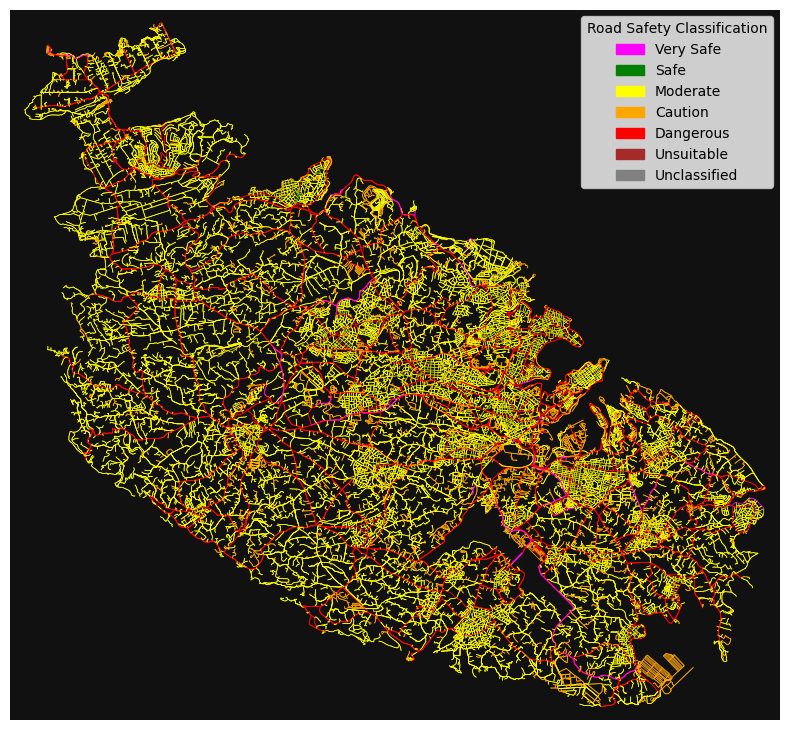

In [40]:
plotting.plot_road_classification(my_graph.G_master)

In [41]:
"""investigation.analyze_parallel_edges(my_graph.G_master)
investigation.compare_parallel_edges(my_graph.G_master)
investigation.plot_parallel_edges(my_graph.G_master)
print("-----")"""

'investigation.analyze_parallel_edges(my_graph.G_master)\ninvestigation.compare_parallel_edges(my_graph.G_master)\ninvestigation.plot_parallel_edges(my_graph.G_master)\nprint("-----")'

## Topology

Fetched elevations for 35755 / 35755 nodes


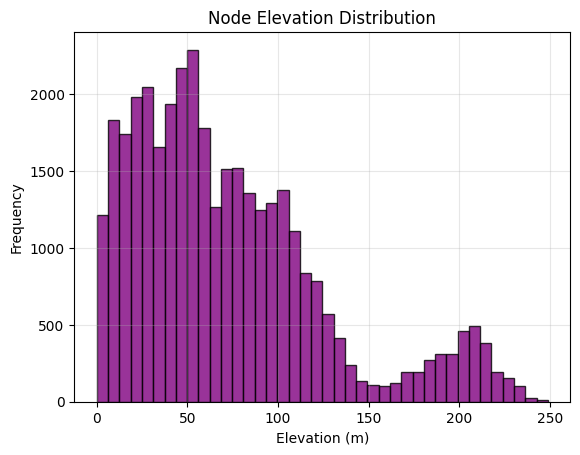

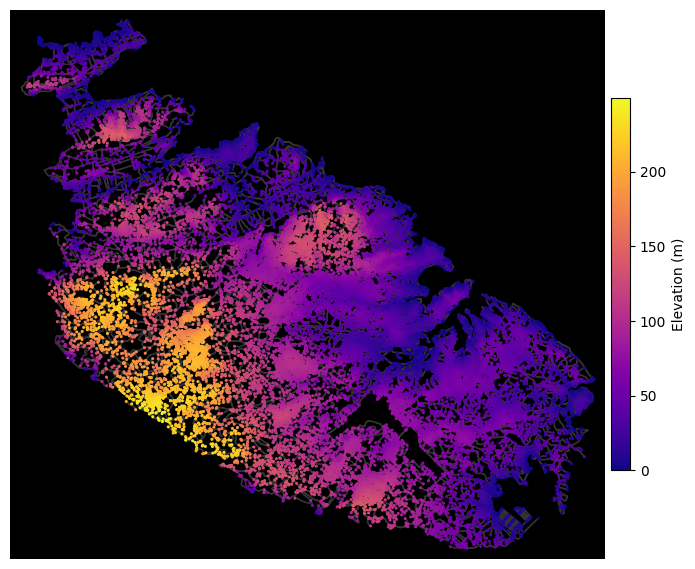

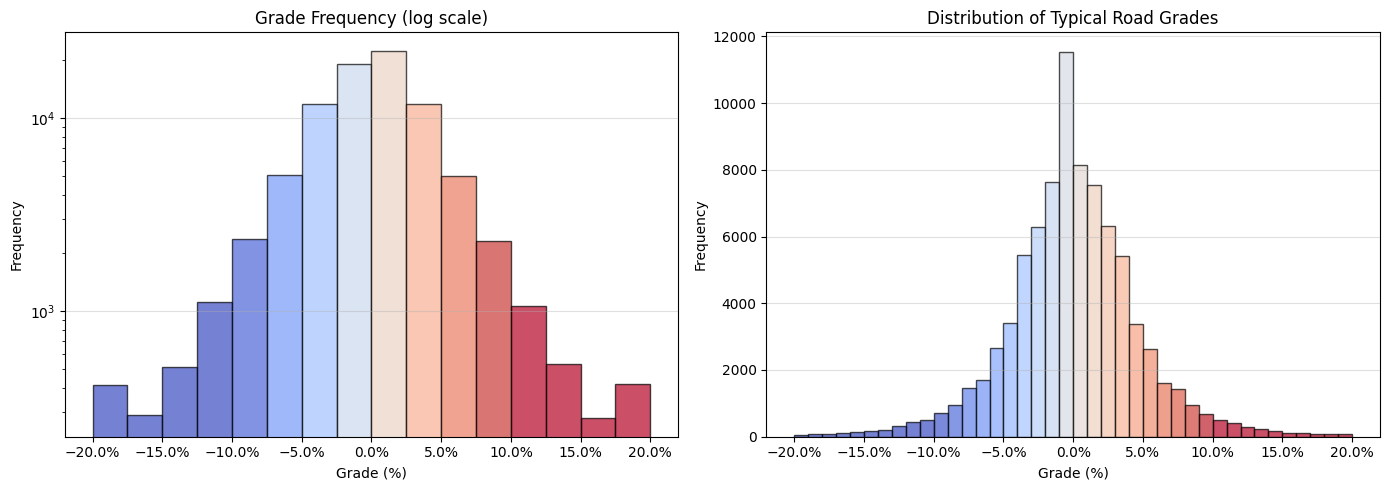

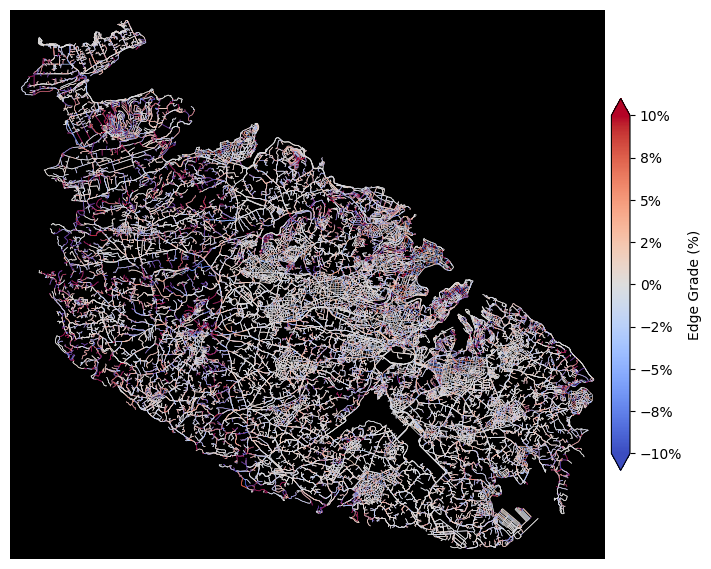

In [42]:
plotting.plot_elevation(my_graph.G_master)
plotting.plot_grades(my_graph.G_master)

## Network statistics

In [43]:
"""# what sized area does our network cover in square meters?
bike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes
graph_area_m = bike_nodes_proj.union_all().convex_hull.area
# show some basic stats about the network
stats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)"""

'# what sized area does our network cover in square meters?\nbike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes\ngraph_area_m = bike_nodes_proj.union_all().convex_hull.area\n# show some basic stats about the network\nstats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)'

In [44]:
edge_keys = set()
for u,v,data in my_graph.G_master.edges(data=True):
    edge_keys.update(data.keys())
print(edge_keys)

{'bike_lanes', 'highway', 'bike_allowed', 'risk_factor', 'name', 'grade_abs', 'geometry', 'car_allowed', 'cycleway', 'length', 'safety', 'osmid', 'width', 'bicycle', 'tunnel', 'oneway', 'name:en', 'car_lanes', 'bridge', 'grade', 'reversed'}


## Road development context

In [45]:
def fuzzy_match(name, targets, threshold=0.75):
    """Return True if name is similar to any target above threshold."""
    if not name:
        return False
    name = name.lower()
    for t in targets:
        if SequenceMatcher(None, name, t.lower()).ratio() >= threshold:
            print(f"matched '{name}' and '{t.lower()}'")
            return True
    return False

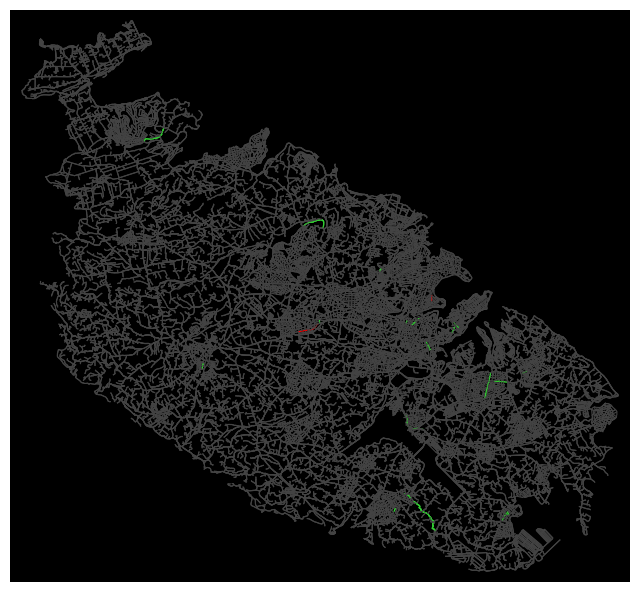


⚠️  Planned roads NOT found in OSM data:
  • Pjazza Tumas Dingli
  • Ix-Xatt iċ-Ċangatura
  • Triq il-Poetra Nazzjonali
  • Pjazzetta Anġlu Gatt
  • Misraħ Is-Saqqaja
  • Triq Mons. Mikiel Azzopardi
  • Misraħ Ħal Kirkop
  • Misraħ Santa Maria

⚠️  Recently constructed roads NOT found in OSM data:
  • L-Imdina road
  • Il-Konvoj ta' Santa Marija Street
  • Il-Belt Valletta Road
  • Manwel Dimech Street
  • Paola Road
  • Anton Buttigieg Road
  • Il-Hamsa u Ghoxrin ta' Novembru Avenue
  • Fisher Street
  • Sant' Anton Street
  • Cipru Street
  • Gibiltá Street
  • Il-Libja Street
  • Il-Marokk Street
  • Korfu Street
  • L-Argentina Street
  • L-Ingilterra Street
  • Ic-Cili Street
  • Il-Brazil Street
  • Il-Mithna Street
  • Spanja Street
  • It-Tuffieh Street


In [46]:
planned_bike_construction = [
    "Triq Hompesch",
    "Triq Oscar Zammit",
    "Pjazza Tumas Dingli",
    "Triq Emvin Cremona",
    "Ix-Xatt iċ-Ċangatura",
    "Triq il-Poetra Nazzjonali",
    "Triq Selmun",
    "Pjazzetta Anġlu Gatt",
    "Triq John Adye",
    "Misraħ Is-Saqqaja",
    "Misraħ il-Knisja",
    "Triq Mons. Mikiel Azzopardi",
    "Triq San Tumas",
    "Misraħ Ħal Kirkop",
    "Misraħ Santa Maria",
]

recently_constructed = [
    "Triq iż-Żagħfran",
    "Triq in-Nutar Żarb",
    "L-Imdina road",  # partial match ok
    "Il-Konvoj ta' Santa Marija Street",
    "Il-Belt Valletta Road",
    "Manwel Dimech Street",
    "Abate Rigord Street",
    "Paola Road",
    "Anton Buttigieg Road",
    "Il-Hamsa u Ghoxrin ta' Novembru Avenue",
    "Fisher Street",
    "Sant' Anton Street",
    "Cipru Street",
    "Gibiltá Street",
    "Il-Libja Street",
    "Il-Marokk Street",
    "Korfu Street",
    "L-Argentina Street",
    "L-Ingilterra Street",
    "Ic-Cili Street",
    "Il-Brazil Street",
    "Il-Mithna Street",
    "Spanja Street",
    "It-Tuffieh Street",
]

edge_colors = []
found_green, found_red = set(), set()

#NOTE through testing of a typical example, this had a ratio of 0.68
# match = SequenceMatcher(None, "Triq Manwel Dimech", "Manwel Dimech Street").ratio()
threshold = 0.68  # adjust sensitivity (0.7–0.8 usually good)

for u, v, k, data in my_graph.G_master.edges(keys=True, data=True):
    name = data.get("name", "")
    en_name = data.get("name:en", "")
    color = "#444444"  # default gray

    # Collect both 'name' and 'name:en'
    raw_names = []
    for val in (name, en_name):
        if isinstance(val, list):
            raw_names.extend(val)
        elif val:
            raw_names.append(val)

    if not raw_names:
        edge_colors.append(color)
        continue

    road_names = [str(n).lower() for n in raw_names]  # combined names


    # Check each category
    if any(any(target.lower() in n for n in road_names) for target in planned_bike_construction):
        color = "limegreen"
        found_green.update(road_names)
    elif any(any(target.lower() in n for n in road_names) for target in recently_constructed):
        color = "red"
        found_red.update(road_names)

    edge_colors.append(color)


fig, ax = ox.plot.plot_graph(
    my_graph.G_master,
    node_size=0,
    edge_color=edge_colors,
    edge_linewidth=0.8,
    bgcolor="k",
    show=True
)


found_green_normalized = {n.lower() for n in found_green}
found_red_normalized = {n.lower() for n in found_red}

not_found_green = [
    r for r in planned_bike_construction if r.lower() not in found_green_normalized
]
not_found_red = [
    r for r in recently_constructed if r.lower() not in found_red_normalized
]

if not_found_green:
    print("\n⚠️  Planned roads NOT found in OSM data:")
    for r in not_found_green:
        print("  •", r)

if not_found_red:
    print("\n⚠️  Recently constructed roads NOT found in OSM data:")
    for r in not_found_red:
        print("  •", r)

# Topological Metrics

Evaluating how good a network is

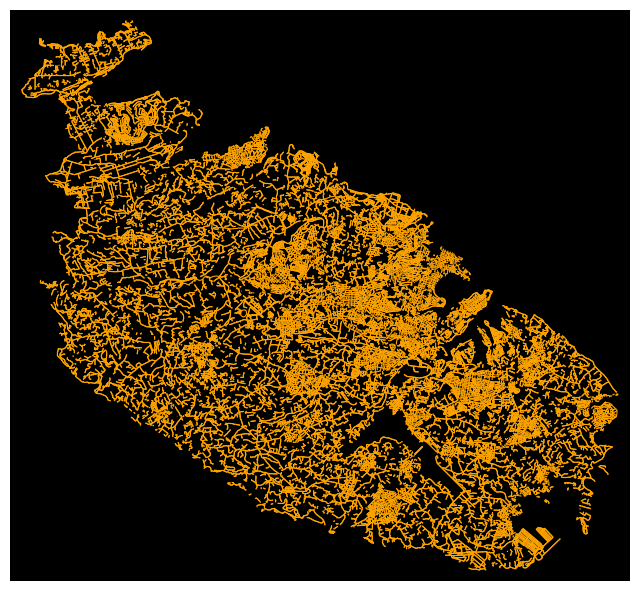

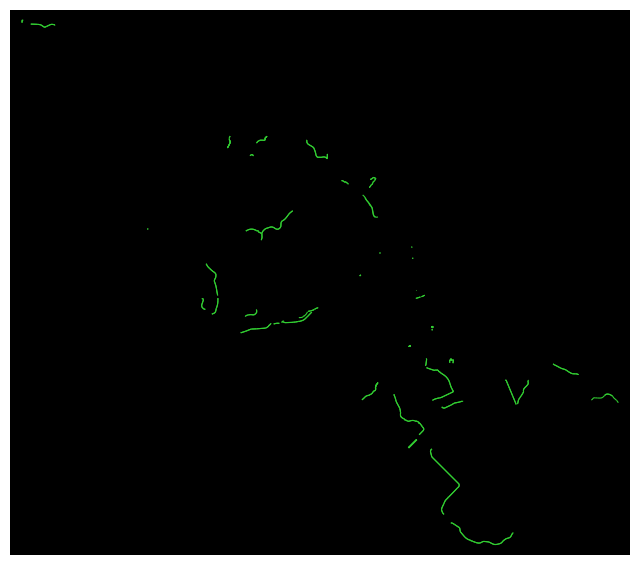

In [47]:
fig, ax = ox.plot_graph(
    my_graph.make_bikeable_subgraph(my_graph.G_master),
    node_size=0,
    edge_color="orange",
    edge_linewidth=0.8,
    bgcolor="k"
)

fig, ax = ox.plot_graph(
    my_graph.make_protected_subgraph(my_graph.G_master),
    node_size=0,
    edge_color="limegreen",
    edge_linewidth=0.8,
    bgcolor="k"
)

In [48]:
# Connectedness - describing whether the network forms a single, navigable system or remains fragmented into multiple component
def calc_connectedness(G:MultiDiGraph, G_lcc:MultiDiGraph) -> dict:
    num_components = nx.number_strongly_connected_components(G)
    lcc_length = float(sum(d.get("length", 0) for _, _, d in G_lcc.edges(data=True)))

    return {
        "num_components": num_components,
        "lcc_length": lcc_length,
    }


"""def calc_directness(Gb_lcc:MultiDiGraph, G_drive:MultiDiGraph, k = SAMPLE_K, seed=SEED):
    #TODO update when I actually have OD matrix data
    rng = random.Random(seed)

    nodes_b = list(Gb_lcc.nodes())
    if len(nodes_b) < 2:
        raise ValueError("Bike LCC has fewer than 2 nodes.")
    K_eff = min(k, len(nodes_b) * 5)  # keep reasonable number of pairs
    rng.seed(seed)
    ods = []
    while len(ods) < K_eff:
        o = rng.choice(nodes_b)
        d = rng.choice(nodes_b)
        if o != d:
            ods.append((o, d))
            
    pass"""

def calc_centrality(G_lcc:MultiDiGraph, k=SAMPLE_K, seed = SEED) -> dict:
    """Calculate comprehensive centrality metrics for cycling network assessment"""
    #NOTE full centrality is O(n^3), k is instead used to approximate

    num_nodes = len(G_lcc.nodes)
    k_eff = min(k, num_nodes)
    
    # Edge betweenness centrality - connectors for network resilience
    edge_between_cent = nx.edge_betweenness_centrality(G_lcc, weight="length", normalized=True, k=k_eff, seed = seed)
    mean_edge_between_cent = float(np.mean(list(edge_between_cent.values())))

    # betweenness centrality - measures how frequently a link lies on the shortest paths between all node pair
    node_between_cent = nx.betweenness_centrality(G_lcc, weight="length", normalized=True, k=k_eff, seed = seed)
    mean_node_between_cent = float(np.mean(list(node_between_cent.values())))

    #closeness_centrality - how close all other nodes are 
    node_close_cent = nx.closeness_centrality(G_lcc, distance="length")
    mean_node_close_cent = float(np.mean(list(node_close_cent.values())))

    degrees = [d for _, d in G_lcc.degree()]
    mean_degree = float(np.mean(degrees))
        
    return {
        "mean_edge_betweenness": mean_edge_between_cent,
        "mean_node_betweenness": mean_node_between_cent,
        "mean_node_closeness": mean_node_close_cent,
        "mean_degree": mean_degree,
    }


def network_evaluation(G:MultiDiGraph) -> dict:
    G_lcc = ox.truncate.largest_component(G, strongly=True) #NOTE strongly connected true since roads cycle infrastructure is directional

    connectedness = calc_connectedness(G, G_lcc)
    centrality  = calc_centrality(G_lcc)
    results = {**connectedness, **centrality}
    return results

In [49]:
# Directness - measures how efficiently users can travel between two point

# Centrality
network_evaluation(my_graph.make_protected_subgraph(my_graph.G_master))
## Degree - number of connections per node

{'num_components': 71,
 'lcc_length': 102359918.91440608,
 'mean_edge_betweenness': 0.18888888888888886,
 'mean_node_betweenness': 0.33333333333333337,
 'mean_node_closeness': 6.188969074572137e-08,
 'mean_degree': 3.75}

# Optimisation Approaches 

## Heuristic Approaches

Centrality - betweeness and closeness

In [50]:
def heuristic(G_master:MultiDiGraph, k=SAMPLE_K, seed=SEED):
    G_drive = my_graph.make_drive_subgraph(G_master)
    edges_between_cent = nx.edge_betweenness_centrality(G_drive, weight="length", normalized=True, k=k, seed=seed)
    max_between_cent_edge = max(edges_between_cent, key=edges_between_cent.get)
    print(max_between_cent_edge)
    
    u,v,k = max_between_cent_edge
    #print(f"edge before: {G_master[u][v][k]}")
    my_graph.reallocate_edge(G_master, max_between_cent_edge)
    #print(f"edge after: {G_master[u][v][k]}" )

(9250737080, 378205575, 0)
(9250737080, 378205575, 0)
(9250737080, 378205575, 0)
(9250737080, 378205575, 0)
(9250737080, 378205575, 0)
(5208448744, 2825796732, 0)
(5208448744, 2825796732, 0)
(146730551, 13130476699, 0)
(146730551, 13130476699, 0)
(7701407392, 7701407395, 0)


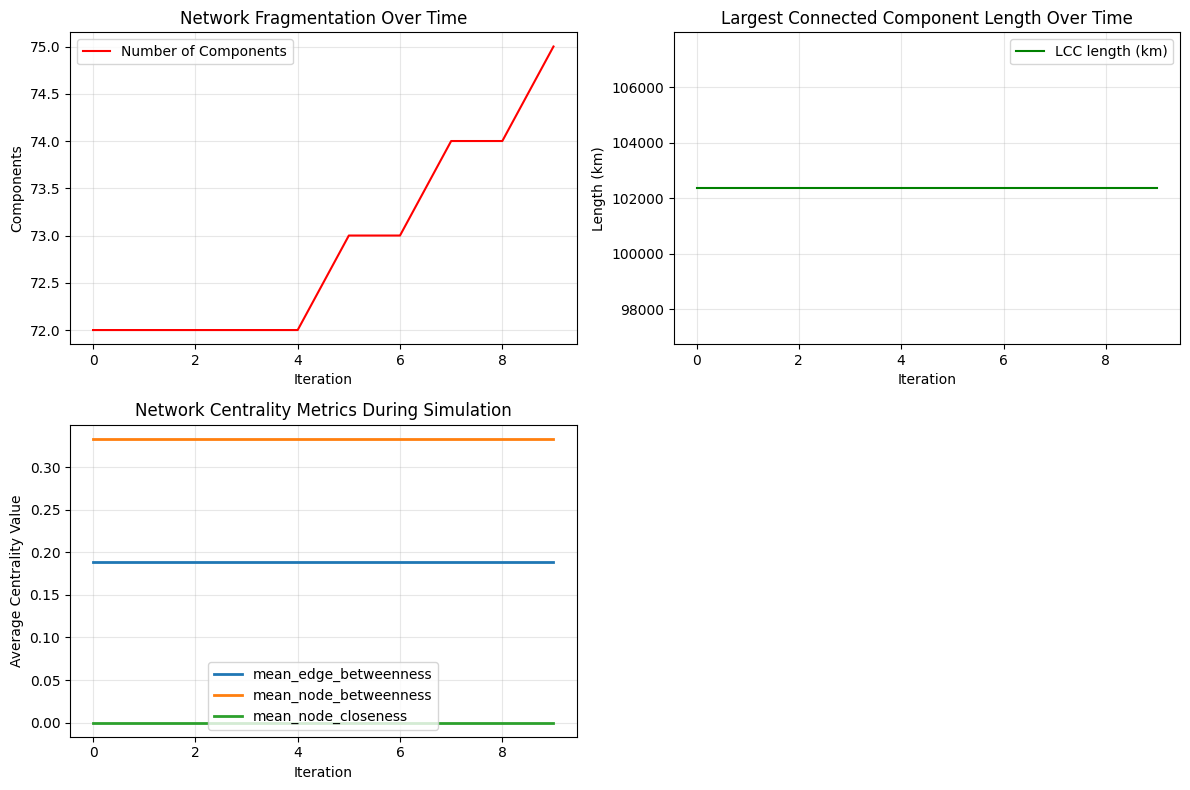

In [51]:
def run_simulation(graphs:GraphManager):
    G_working = copy.deepcopy(graphs.G_master)

    evaluations = []
    for i in range(10):
        #print(f"{i}th iteration running...")
        #NOTE heuristic is taking too much time
        heuristic(G_working, k=10)
        #print("heuristic complete")

        protected_subgraph = graphs.make_protected_subgraph(G_working)
        #print("making protected subgraph")
        evaluation = network_evaluation(protected_subgraph)
        #print("evaluating protected subgraph")
        evaluations.append(evaluation)
    
    return evaluations

results = run_simulation(my_graph)

df_results = pd.DataFrame(results)
df_results.index.name = "iteration"

plotting.plot_evaluation(df_results)
